In [12]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, GridSearchCV, cross_val_predict
from sklearn.svm import SVR
from sklearn.metrics import r2_score

from skopt.learning import GaussianProcessRegressor
from skopt.learning.gaussian_process.kernels import RBF, Matern, ConstantKernel as C, RationalQuadratic

from scipy.interpolate import PchipInterpolator as Pchip
from scipy.interpolate import RBFInterpolator
from scipy.stats import pearsonr, spearmanr, skew, kurtosis

import matplotlib.pyplot as plt

from pathlib import Path

import json
import joblib
import hashlib
import sklearn
import skopt


# Import

In [13]:
cwd = Path.cwd()

version='v15'
sampling_data_path=Path(f'{cwd}/results_{version}/morris_samples_{version}.csv').resolve()
results_path=Path(f"{cwd}/results_{version}/results/raw_data").resolve()
field_data_path=Path(f"{cwd}/STIMTEC_example/BH10_20180718_40.6_SR_v2.csv")

raw_paths= list((results_path).glob("*.npy"))

file_paths= sorted(
    raw_paths,
    key= lambda p: int(p.stem.split("_")[2])
)

iter_list=[np.load(file,allow_pickle=True).item() for file in file_paths]
sampling_data=pd.read_csv(sampling_data_path,header=0)
field_data=pd.read_csv(field_data_path,header=0)



# Functions

In [14]:
def y_cv_pred_rmse(grid_search, X_scaled, y_log, cv:int = 5)-> None:
    y_cv_pred_log = cross_val_predict(
        grid_search.best_estimator_, X_scaled, y_log, cv = cv
    )



def opt_skopt_gp( X, y, param_grid = None, n_splits: int = 5, random_state: int = 42 ):
    """
    Optimises GP for data 
    """

    pipeline = Pipeline([
        ('scaler', MinMaxScaler()),
        ('gp', GaussianProcessRegressor(
        n_restarts_optimizer= 5, 
        normalize_y= True,
        random_state= random_state
         ))
    ]) 

    if param_grid is None :
        param_grid = {
            'gp__alpha'  : [1e-10, 1e-5, 1e-2, 1e-1],
            'gp__noise'  : ['gaussian', 1e-5, 1e-2,1e-1],
            'gp__kernel' : [
                C(1.0)*RBF(length_scale=1.0),
                C(1.0)*Matern(length_scale=1.0, nu=1.5),
                C(1.0)*Matern(length_scale=1.0, nu=2.5),
                C(1.0)*RationalQuadratic(length_scale=1.0, alpha=1.0),
            ]
        }

    cv = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    scoring = {
        'MAE' : 'neg_mean_absolute_error',
        'R2'  : 'r2',
        'RMSE': 'neg_root_mean_squared_error'
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid= param_grid,
        cv=cv,
        scoring=scoring,
        refit= 'MAE', #reference fitting
        n_jobs= -1
    )

    grid_search.fit(X,y)

    cv_results = pd.DataFrame(grid_search.cv_results_)

    summary = pd.DataFrame ({
        'Params': cv_results['params'],
        'Mean MAE': -cv_results['mean_test_MAE'],
        'Std MAE': cv_results['std_test_MAE'],
        'Mean R2': cv_results['mean_test_R2'],
        'Mean RMSE': -cv_results['mean_test_RMSE']
    }).sort_values(by='Mean MAE', ascending= True).reset_index(drop= True)

    print('='*60)
    print('SKOPT GAUSSIAN PROCESS OPTIMISATION COMPLETE')
    print('='*60)
    print(f'Best Validation MAE: {-grid_search.best_score_:.6f}')
    print(f'Best Validation R2: {summary.loc[0, 'Mean R2']:.6f}')
    print(f'Best Validation RMSE: {summary.loc[0, 'Mean RMSE']:.6f}')
    print('='*60)
    print('Best Parameters:')
    for param, val in grid_search.best_params_.items():
        print(f' {param}: {val}')
    print('='*60)

    return grid_search, summary, cv

def tune_crossv_RBF(df_raw: pd.DataFrame, factor_cols: list[str], target_col = 'NRMSE', n_splits:int=5 ) -> None:
    """ 
    Stack 3D factors, run KFold cv hyper grid search
    Generates out-of-fold CV prediction and oberserver
    Computes Cross correlation metrics (of subspaces)
    """
    combo_key = "_".join(factor_cols)

    df_raw_rmse = df_raw['log_rmse'].values.reshape(-1,1) #log or normal y-target
    df_raw_rmse_scaler = MinMaxScaler().fit(df_raw_rmse)
    df_raw[target_col] = df_raw_rmse_scaler.transform(df_raw_rmse).ravel()

    stacked_df = df_raw.groupby(factor_cols, as_index= False)[target_col].min()
    X_raw = stacked_df[factor_cols].values
    y_raw = stacked_df[target_col].values

    scaler_X = MinMaxScaler().fit(X_raw)
    scaler_y = MinMaxScaler().fit(y_raw.reshape(-1,1)) #double for adjusting rbf fitting

    X_norm = scaler_X.transform(X_raw)
    y_norm = scaler_y.transform(y_raw.reshape(-1,1)).ravel() 

    param_grid = [
        {'kernel' : 'thin_plate_spline', 'smoothing' : [0.0, 1e-4, 1e-2, 1e-1, 1.0]},
        {'kernel' : 'cubic', 'smoothing' : [0.0, 1e-4, 1e-2, 1e-1,1.0]},
        {'kernel' : 'gaussian', 'epsilon' : [0.0, 1e-4, 1e-2, 1e-1,1.0], 'smoothing': [0.0, 1e-4, 1e-2, 1e-1,1.0]},
        {'kernel' : 'multiquadratic', 'epsilon' : [0.0, 1e-4, 1e-2, 1e-1,1.0], 'smoothing': [0.0, 1e-4, 1e-2, 1e-1,1.0]}
    ]

    kf = KFold(n_splits= n_splits, shuffle= True, random_state=42)

    best_overall_score = float('inf')
    best_paras = {}
    best_oof_preds_norm = None

    for group in param_grid:
        kernel = group['kernel']
        epsilons = group.get('epsilon', [None])
        smoothings = group['smoothing']

        for eps in epsilons:
            for smooth in smoothings:
                oof_preds = np.zeros_like(y_norm)

                for train_idx, val_idx in kf.split(X_norm):
                    X_tr, X_val = X_norm[train_idx], X_norm[val_idx]
                    y_tr = y_norm[train_idx]

                    kwargs = {'kernel': kernel, 'smoothing': smooth}
                    if eps is not None:
                        kwargs['epsilon'] = eps

                    try: 
                        rbf = RBFInterpolator(X_tr, y_tr, **kwargs)
                        oof_preds[val_idx] = rbf(X_val)
                    except Exception:
                        oof_preds[val_idx] = np.nan

                rmse = np.sqrt(np.mean((y_norm - oof_preds)**2))

                if rmse < best_overall_score:
                    best_overall_score = rmse
                    best_params = {'kernel': kernel, 'epsilon': eps, 'smoothing': smooth }
                    best_oof_preds_norm = oof_preds.copy()

        y_cv_pred = scaler_y.inverse_transform(best_oof_preds_norm.reshape(-1,1)).ravel()

        p_corr, _ = pearsonr(y_raw, y_cv_pred)
        s_corr, _ = spearmanr(y_raw, y_cv_pred)
        r2        = r2_score(y_raw, y_cv_pred)

        final_kwargs = {'kernel': best_params['kernel'], 'smoothing': best_params['smoothing']}
        if best_params['epsilon'] is not None:
            final_kwargs['epsilon'] = best_params ['epsilon']

        final_model = RBFInterpolator(X_norm, y_norm, **final_kwargs)

        #export saving machine ready archive
        bundle = {
            'factor_cols': factor_cols,
            'combo_key' : combo_key,
            'model' : final_model,
            'scaler_X': scaler_X,
            'scaler_y' : scaler_y,
            'best_params': best_params,
            'evaluation_data': {
                'y_observed': y_raw,
                'y_cv_predicted': y_cv_pred,
                'pearson_corr': p_corr,
                'spearman_corr': s_corr,
                'r2_score': r2,
                'cv_nrmse_score': best_overall_score
            }
        }

        print(f"[{combo_key} Best kernel: {best_params['kernel']} | Pearson R: {p_corr:.4f} | R2: {r2:.4f}]")    
        return bundle

                     


def objective_function(npyresult: dict,datafield: pd.DataFrame):

    t_source=np.array(npyresult["timevalues"])
    p_source=np.array(npyresult["values"]) #values, either pressure or other variable
    p_field=datafield["Pint_downhole [MPa]_s"]*1e6 #Pa values

    # sort_idx= np.argsort(t_source) #sortingin case no order in output
    # t_source=t_source[sort_idx]
    # p_source=p_source[sort_idx]

    f= Pchip(t_source,p_source)
    p_interp=f(datafield["Zeit [s]"])

    rmse=np.sqrt(np.mean((p_interp-p_field)**2))

    return rmse

def rmsle_ep(npyresult: dict,datafield: pd.DataFrame, epsilon: float = 100.0) -> np.array:
    "ln(y + epsilon ) transformation"

    t_source=np.array(npyresult["timevalues"])
    p_source=np.array(npyresult["values"]) #values, either pressure or other variable
    p_field=datafield["Pint_downhole [MPa]_s"]*1e6 #Pa values

    # sort_idx= np.argsort(t_source) #sortingin case no order in output
    # t_source=t_source[sort_idx]
    # p_source=p_source[sort_idx]

    f= Pchip(t_source,p_source)
    p_interp=f(datafield["Zeit [s]"])

    p_int_ln = np.log(p_interp + epsilon)
    p_field_ln = np.log(p_field + epsilon)

    rmsle=np.sqrt(np.mean((p_int_ln-p_field_ln)**2))

    return rmsle


# Input checkings

## Functions

In [15]:
def analysis_dist(series: pd.Series, name: str = None) -> dict:
    """ Histograms/KDE and distribution"""
    clean_series = series.dropna()
    col_name = name or series.name or "Variable"

    stats = {
        "Variable": col_name,
        "Min" : clean_series.min(),
        "Max" : clean_series.max(),
        "Mean" : clean_series.mean(),
        "Std" : clean_series.std(),
        "Skewness" : skew(clean_series),
        "Kurtosis" : kurtosis(clean_series)
    }

    print(f" - {col_name} - | Skew: {stats['Skewness']:.2f} | Kurtosis: {stats['Kurtosis']:.2f} |Range: [ {stats['Min']:.2e}, {stats['Max']:.2e}] ")

    plt.figure(figsize=(6,3))
    clean_series.plot(kind = "hist", bins = 20, density = True, alpha= 0.5, color = "Navy")
    clean_series.plot(kind = "kde", color = "red", lw = 2)
    plt.title(f"Distribution: {col_name} (Skew: {stats['Skewness']:.2f})")
    plt.xlabel(col_name)
    plt.grid(True, ls= "--", alpha= 0.5)
    plt.tight_layout()
    plt.show()

    return stats


## Processing

In [16]:
#prepare

rmse=[objective_function(iter_,field_data) for iter_ in iter_list]
rmse = np.array(rmse)
sampling_data['rmse'] = rmse

rmsle=[rmsle_ep(iter_,field_data) for iter_ in iter_list]
rmsle = np.array(rmsle)
sampling_data['rmsle'] = rmsle



 - Pre-stack_sf0 - | Skew: 0.02 | Kurtosis: -1.45 |Range: [ 2.09e-10, 8.50e-04] 


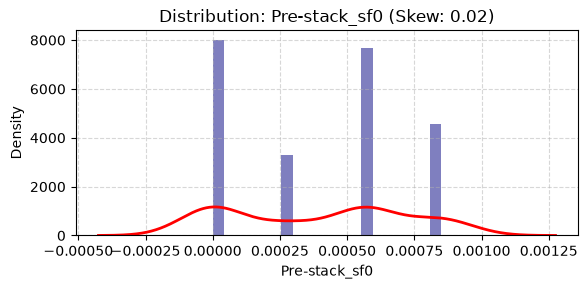

 - Pre-stack_pjack - | Skew: 0.10 | Kurtosis: -1.22 |Range: [ 3.10e+06, 3.60e+06] 


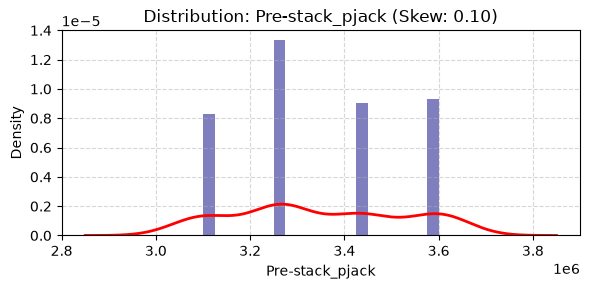

 - Pre-stack_wr - | Skew: -0.13 | Kurtosis: -1.46 |Range: [ 2.00e+05, 5.00e+05] 


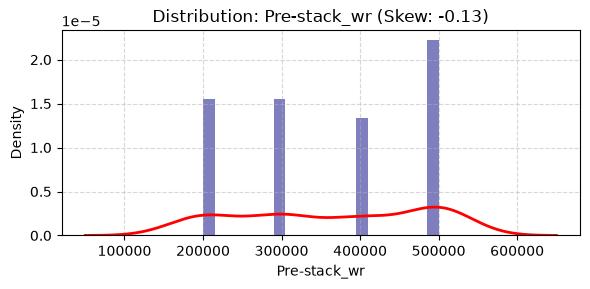

 - Pre-stack_L - | Skew: 0.05 | Kurtosis: -1.35 |Range: [ 5.00e-01, 2.00e+01] 


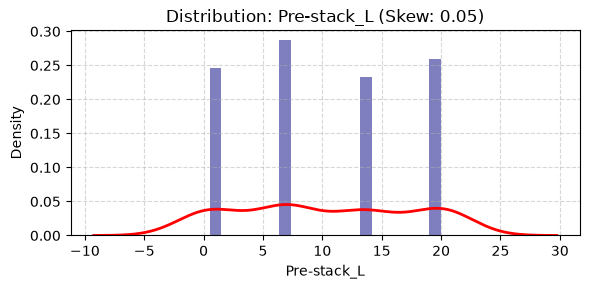

 - Pre-stack_rmse - | Skew: 1.14 | Kurtosis: -0.30 |Range: [ 2.91e+05, 2.30e+06] 


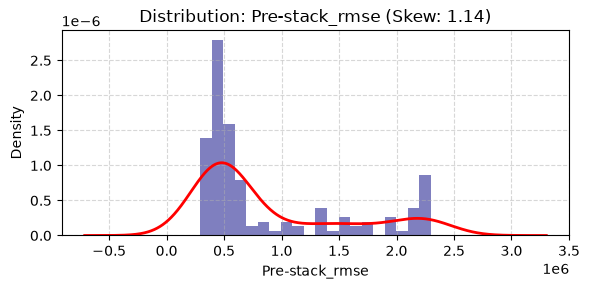

 - Pre-stack_rmsle - | Skew: 2.30 | Kurtosis: 4.70 |Range: [ 2.35e-01, 1.37e+00] 


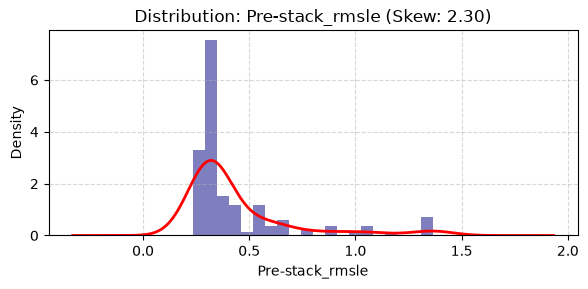

In [17]:
#pre-stack checking

cols_check = sampling_data.columns.tolist()
pre_stats = {}
for col in cols_check:
    pre_stats[col] = analysis_dist(sampling_data[col],name= f"Pre-stack_{col}")

In [22]:
#stacked checking
def df_stacking(df_raw: pd.DataFrame,factor_cols:list[str], target_col:str = 'rmse'):

    stacked_df = df_raw.groupby(factor_cols, as_index= False)[target_col].min()
    return stacked_df

combos = {'combo_1':['pjack','wr','L'],
          'combo_2': ['pjack','wr','sf0']
}

stacked_df= {}
for key_, value in combos.items():
    stacked_df[key_] = df_stacking(sampling_data, value, 'rmsle') # adjus rmse or rmsle



 - Post-stack_pjack - | Skew: -0.03 | Kurtosis: -1.30 |Range: [ 3.10e+06, 3.60e+06] 


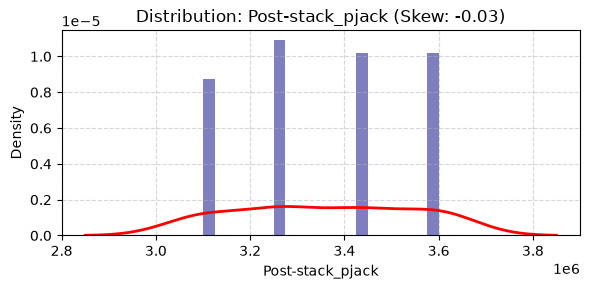

 - Post-stack_wr - | Skew: -0.02 | Kurtosis: -1.45 |Range: [ 2.00e+05, 5.00e+05] 


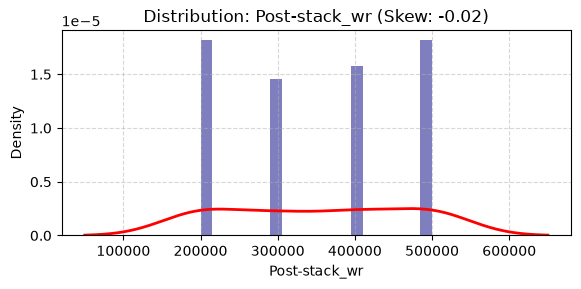

 - Post-stack_L - | Skew: -0.03 | Kurtosis: -1.26 |Range: [ 5.00e-01, 2.00e+01] 


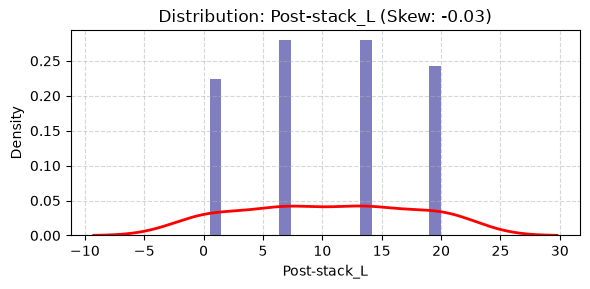

 - Post-stack_rmsle - | Skew: 3.52 | Kurtosis: 15.39 |Range: [ 2.35e-01, 6.77e-01] 


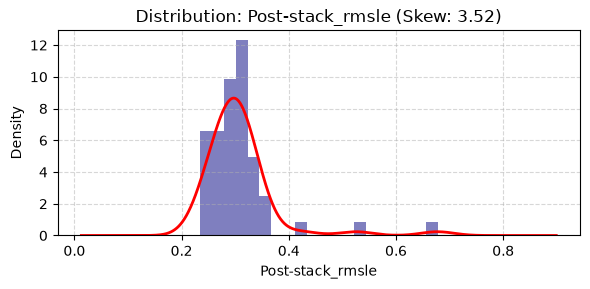

In [23]:
post_stats = {}
combo_check = 'combo_1'
for name, slice in stacked_df[combo_check].items():
   post_stats[name] = analysis_dist(slice, name= f"Post-stack_{name}")


## Transforming factors/variables with high skew-range

The transformation is given in new variables with log10

In [ ]:
sampling_data['log_sf0'] = np.log(sampling_data['sf0'])
sampling_data['log_rmse'] = np.log10(sampling_data['rmse'])

In [ ]:
grid_search.cv_results_

32

# Gaussian Process Regressor Hyper-p tunning

In [ ]:
#slice-preparing
sampling_data_ready= sampling_data[['pjack','wr','L', 'log_sf0','log_rmse']].copy()

In [ ]:
grid_search, summary, cv = opt_skopt_gp(sampling_data_ready[['pjack','wr','L','log_sf0',]],sampling_data_ready[['log_rmse']])

SKOPT GAUSSIAN PROCESS OPTIMISATION COMPLETE
Best Validation MAE: 0.249608
Best Validation R2: -0.050029
Best Validation RMSE: 0.281464
Best Parameters:
 gp__alpha: 0.1
 gp__kernel: 1**2 * Matern(length_scale=1, nu=1.5)
 gp__noise: gaussian


## Save metadata GP

In [ ]:
def export_tunning_results(grid_search, X_df, feature_names, export_prefix='gp_tunning'):
    best_pipeline = grid_search.best_estimator_
    best_gp = best_pipeline.named_steps['gp']
    scaler = best_pipeline.named_steps['scaler']

    hyperparams_log = {
        "metadata" : {
            "n_samples": X_df.shape[0],
            "n_features" : X_df.shape[1],
            "feature_names" : feature_names,
            "data_hash" : hashlib.md5(X_df.values.tobytes()).hexdigest(),
            "environment": {
                "sklearn_version" : sklearn.__version__,
                "skopt_version" : skopt.__version__
            }
        },
        "performance_metrics": {
            "best_cv_mae": float(-grid_search.best_score_),
            "mean_test_r2": float(grid_search.cv_results_['mean_test_R2'][grid_search.best_index_]),
            "mean_test_rmse": float(-grid_search.cv_results_['mean_test_RMSE'][grid_search.best_index_])
        },
        "scaling_paramters" : {
            "alpha": str(best_gp.kernel_),
            "kernel_str": str(best_gp.kernel_),
            "normalise_y": best_gp.normalize_y,
            "n_restarts_optimizer": best_gp.n_restarts_optimizer
        }
    }

    json_filename = f"{export_prefix}_config.json"
    with open(json_filename, "w") as f:
        json.dump(hyperparams_log, f, indent=4)

    pipeline_filename = f"{export_prefix}_pipeline.pkl"
    joblib.dump(best_pipeline, pipeline_filename)

    print(f"Traceability metadata exported succesfully:")
    print(f" JSON Report: {json_filename}")
    print(f" Pipeline PKL : {pipeline_filename}")


In [ ]:
export_tunning_results(grid_search, sampling_data,list(sampling_data.keys()),"gp_tunning_test")

Traceability metadata exported succesfully:
 JSON Report: gp_tunning_test_config.json
 Pipeline PKL : gp_tunning_test_pipeline.pkl


# RBF Interpolator

In [12]:
sampling_data_ready= sampling_data[['pjack','wr','L', 'log_rmse']].copy()

In [13]:
columns = sampling_data_ready.columns[:-1].tolist() 
print(columns)

['pjack', 'wr', 'L']


In [14]:
bundle = tune_crossv_RBF(sampling_data_ready, columns)

[pjack_wr_L Best kernel: thin_plate_spline | Pearson R: 0.1738 | R2: -0.0732]


In [52]:
type(bundle)

dict

In [15]:

def plot_cv_vs_obs(bundle_):
    """ Plot crossvalidated NRMSE vs Observed NRMSE"""
    if isinstance(bundle_, str):
        bundle_= joblib.load(bundle_)
    else:
        bundle_= bundle_

    eval_data = bundle_['evaluation_data']
    y_obs = eval_data['y_observed']
    y_pred = eval_data['y_cv_predicted']
    combo_key = bundle_['combo_key']

    p_corr = eval_data ['pearson_corr']
    s_corr = eval_data ['spearman_corr']
    r2 = eval_data ['r2_score']

    plt.figure(figsize=(7,6))
    plt.scatter(y_obs, y_pred, alpha= 0.7, edgecolors= "k", label = "Min-stacked samples")

    min_val = min(y_obs.min(), y_pred.min())
    max_val = max(y_obs.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label = '1:1 fit')

    plt.title(f"CV vs Observed NRMSE: {combo_key}\nKernel: {bundle_['best_params']['kernel']}")
    plt.xlabel('Observed NRMSE')
    plt.ylabel("Cross-Validated (K-Fold) predicted NRMSE")

    text_str = f"Pearson R: {p_corr:.4f}\nSpearman R: {s_corr:.4f}\nR2 : {r2:.4f}"
    plt.gca().text(0.05, 0.85, text_str, transform = plt.gca().transAxes,
                   bbox=dict(boxstyle = 'round', facecolor= 'white', alpha = 0.7))

    plt.grid(True, ls= ':', alpha = 0.6)
    plt.legend(loc= 'lower right')
    plt.tight_layout()
    plt.show()

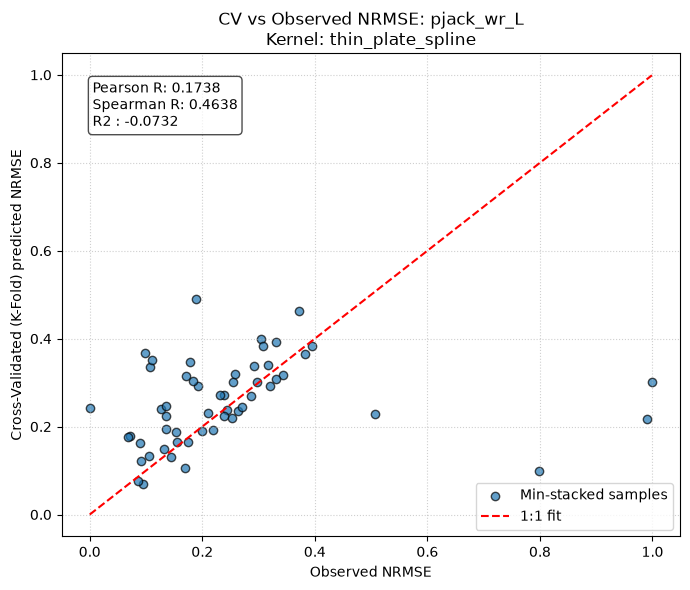

In [16]:
plot_cv_vs_obs(bundle)

## Save metadata RBF

In [ ]:
# export_prefix = 'rbf_3d'
# combo_key = 
# export_filename = f"{export_prefix}_{combo_key}.joblib"
# bundle = tune_crossv_RBF()
# joblib.dump(bundle,export_filename)

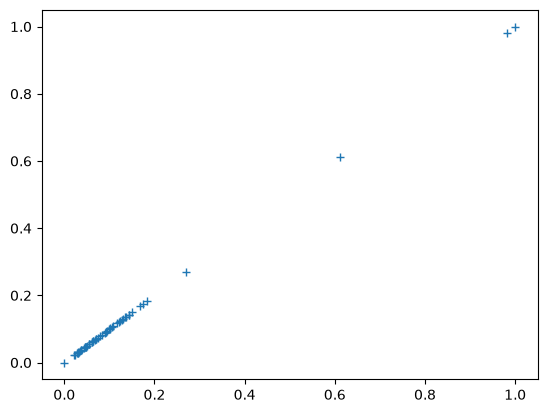

In [ ]:
# plt.plot(y,y,ls='',marker = '+')
# plt.pause(1)